# Introduction to Machine Learning -- MC886
# Assignment 3 - Neural Networks and Overparameterization

**Professor:** Marcelo da Silva Reis  
**PED:** Daniel Gardin Gratti  
**PAD:** Guilherme Henrique Ichiro Seto Ito

In [1]:
# Enter your name and RA number below.
print("Thiago Dorta", "|", "231413")
print("Gabriel Melo Lucena", "|", "184254")

Thiago Dorta | 231413
Gabriel Melo Lucena | 184254


---

## Objective

In Assignment 2 you observed that neural networks can achieve low in-distribution error while failing under distribution shift. This overfitting scenario arises when the model exploits properties present in the training distribution that do not reflect the properties in the underlying data-generating process.

In this assignment, we study how architectural choices and overparameterization interact with inductive bias under distribution shift. In highly parameterized models, multiple distinct mechanisms can explain similar training performance, making it difficult to identify which assumptions about the data are actually responsible for generalization behavior.

For example, a classifier trained on histopathology images may achieve near-perfect training accuracy by either learning morphological features that are stable across imaging sites, or by relying on spurious correlations such as stain-color distributions that coincidentally align with class labels in the training hospitals.
Both solutions fit the training set equally well, but they encode different assumptions about which aspects of the input are relevant, leading to divergent behavior when these correlations are altered or removed in the test distribution.

The goal is to evaluate neural networks as hypothesis classes with different structural assumptions.

### Guidelines

> Please read these guidelines carefully.

1. Answers can be written in English or Portuguese.

2. Use data visualization as a primary tool for understanding. Inspect training data, corrupted inputs, and model behavior. When an assumption is uncertain, verify it empirically through plots.

3. The provided code serves as a reference. Modifications are allowed, including changes to functions and the introduction of new components. Code clarity and organization are required.

4. Use Google Colab or a GPU, if available, to speed up training.

5. The use of generative AI tools (e.g., ChatGPT, GitHub Copilot, DeepSeek, LLaMA) is permitted strictly for **implementation support**. Their use for interpreting, analyzing, or discussing experimental results is discouraged. Submissions must include:
   - A declaration of which models were used.
   - The prompts that generated any incorporated code.

6. Do not hesitate to reach out to the PED/PAD via Discord.

### Experiment structure

Each experiment must follow the structure below:

1. **Question**: the empirical question guiding the exploration.
2. **Hypothesis**: a falsifiable answer to the question that makes a concrete, measurable prediction.
3. **Design**: justify why the proposed experiment can test the hypothesis. Focus on the reasoning, not on how the code works.
4. **Results**: run the experiment and report the metrics.
5. **Discussion**: interpret the results in terms of the hypothesis. Explicitly state whether the results support or contradict it, and why.

A hypothesis must be **falsifiable**: the proposed experiment must be capable of providing evidence *against* it.
Statements such as "the model is complex enough" or "the features are informative" do not qualify.

A negative result is not a failure: a well-reasoned experiment that contradicts the hypothesis is graded as highly as one that confirms it, provided the interpretation is honest and coherent.

For Experiment 1, the question and hypothesis are given. Your task is to complete the missing code, write the design justification, and discuss the results.
For Experiments 2–4, only the question is given. You must state the hypothesis, justify the design, and discuss the results.

In [2]:
import numpy as np
import random

import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import TensorDataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

# ── Reproducibility ────────────────────────────────────────────────────────────
# Do not change this seed. Re-run the notebook from scratch before submitting.
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

DEVICE: str = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cuda


---

## Dataset — Camelyon17

Histopathology is usage of microscopes to study sections of tissues of an organism, often aiming to detect diseases. To this end, one technique involves the usage of oxylin and eosin (H&E)-stained tissue sections. Hematoxylin stains the cell's nucleus in purplish blue, while the eosin stains the cell's cytoplasm and extracellular matrix in pink. Therefore, the pathologist can differentiate structures in a histological section of a tissue.

Here, we will use [Camelyon17](https://camelyon17.grand-challenge.org/), a patch-level histopathology benchmark for tumor detection in H&E-stained lymph node sections. The task is binary classification: **normal tissue** (label 0) vs **tumor tissue** (label 1). Patches were extracted from Whole Slide Images (WSIs) acquired at **five different hospitals** (centers 0–4), each with its own scanner and staining protocol. These differences introduce systematic variation in color, texture, and brightness that is correlated with center identity rather than with tumor status.

**Experimental split:**

| Split | Centers | Role |
|-------|---------|------|
| Train | 0, 3, 4 | In-distribution training |
| Val (ID) | 1 | In-distribution validation — model selection |
| Test (OOD) | 2 | Out-of-distribution test — generalization evaluation |

![example image](https://wilds.stanford.edu/assets/images/dataset_figures/camelyon_dataset.jpg)

The OOD test set (center 2) uses a hospital that the model has never seen during training.
The **ID–OOD gap** in accuracy and AUC is the primary metric for evaluating generalization across all experiments.

The next cell is going to download the data using the [WILDS](https://wilds.stanford.edu/) library, which already
manage the data for us.
It may take a while to download the 10 Gb dataset in disk, but you only need to download it once.
You can also download it manually at https://worksheets.codalab.org/bundles/0xe45e15f39fb54e9d9e919556af67aabe

In [3]:
# Wilds is the library we will use to load the Camelyon17 dataset.
from wilds.datasets.camelyon17_dataset import Camelyon17Dataset
from wilds.common.data_loaders import get_train_loader

# After you have downloaded the dataset once, this cell will load it from your disk.
# If you manually download the dataset, make sure to place it in the "data/camelyon17_v1.0" directory.
dataset = Camelyon17Dataset(root_dir="data", download=True)

You can also download the dataset manually at https://wilds.stanford.edu/downloads.


10658897920Byte [21:59, 8080804.27Byte/s]                                


Extracting data\camelyon17_v1.0\archive.tar.gz to data\camelyon17_v1.0

It took 49.9 minutes to download and uncompress the dataset.



c:\Users\thido\Code\mc886\mc886-projects\mc886_venv\Lib\site-packages\wilds\datasets\camelyon17_dataset.py:74: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_numpy.cpp:212.)
  self._y_array = torch.LongTensor(self._metadata_df['tumor'].values)


In [4]:
# IMPORTANT:
# The dataset is already split into "train", "val", and "test" subsets. Do not change the splits.
# The transform below will be applied to the images when we load them.
# These are the standard transforms used for the ResNet-18 model pretrained on ImageNet.
# (The parameters are the mean and standard deviation of the ImageNet dataset.)
# You can change the transforms if you want, but it is not required.

transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

train_data = dataset.get_subset("train", transform=transform)
val_data = dataset.get_subset("val", transform=transform)
test_data = dataset.get_subset("test", transform=transform)

print(f"Number of training samples: {len(train_data)}")
print(f"Number of validation samples: {len(val_data)}")
print(f"Number of test samples: {len(test_data)}")
print()
print(f"Hospital indices in training set: {torch.unique(train_data.metadata_array[:, 0])}")
print(f"Hospital indices in validation set: {torch.unique(val_data.metadata_array[:, 0])}")
print(f"Hospital indices in test set: {torch.unique(test_data.metadata_array[:, 0])}")

Number of training samples: 302436
Number of validation samples: 34904
Number of test samples: 85054

Hospital indices in training set: tensor([0, 3, 4])
Hospital indices in validation set: tensor([1])
Hospital indices in test set: tensor([2])


---

## Data Exploration

Before start working on the tasks, take a moment to explore the dataset and understand its structure.
Below, we simply observe the samples for each hospital in the training and validation sets.

The goal here is to have a better idea of what our task is, and what problems are already recognizable without
training any model.
Problems such as class imbalance, data invariances, what is the available information in the dataset, can be answered
here.

Conduct a data exploration step to understand what the data looks like, and then write your conclusions.

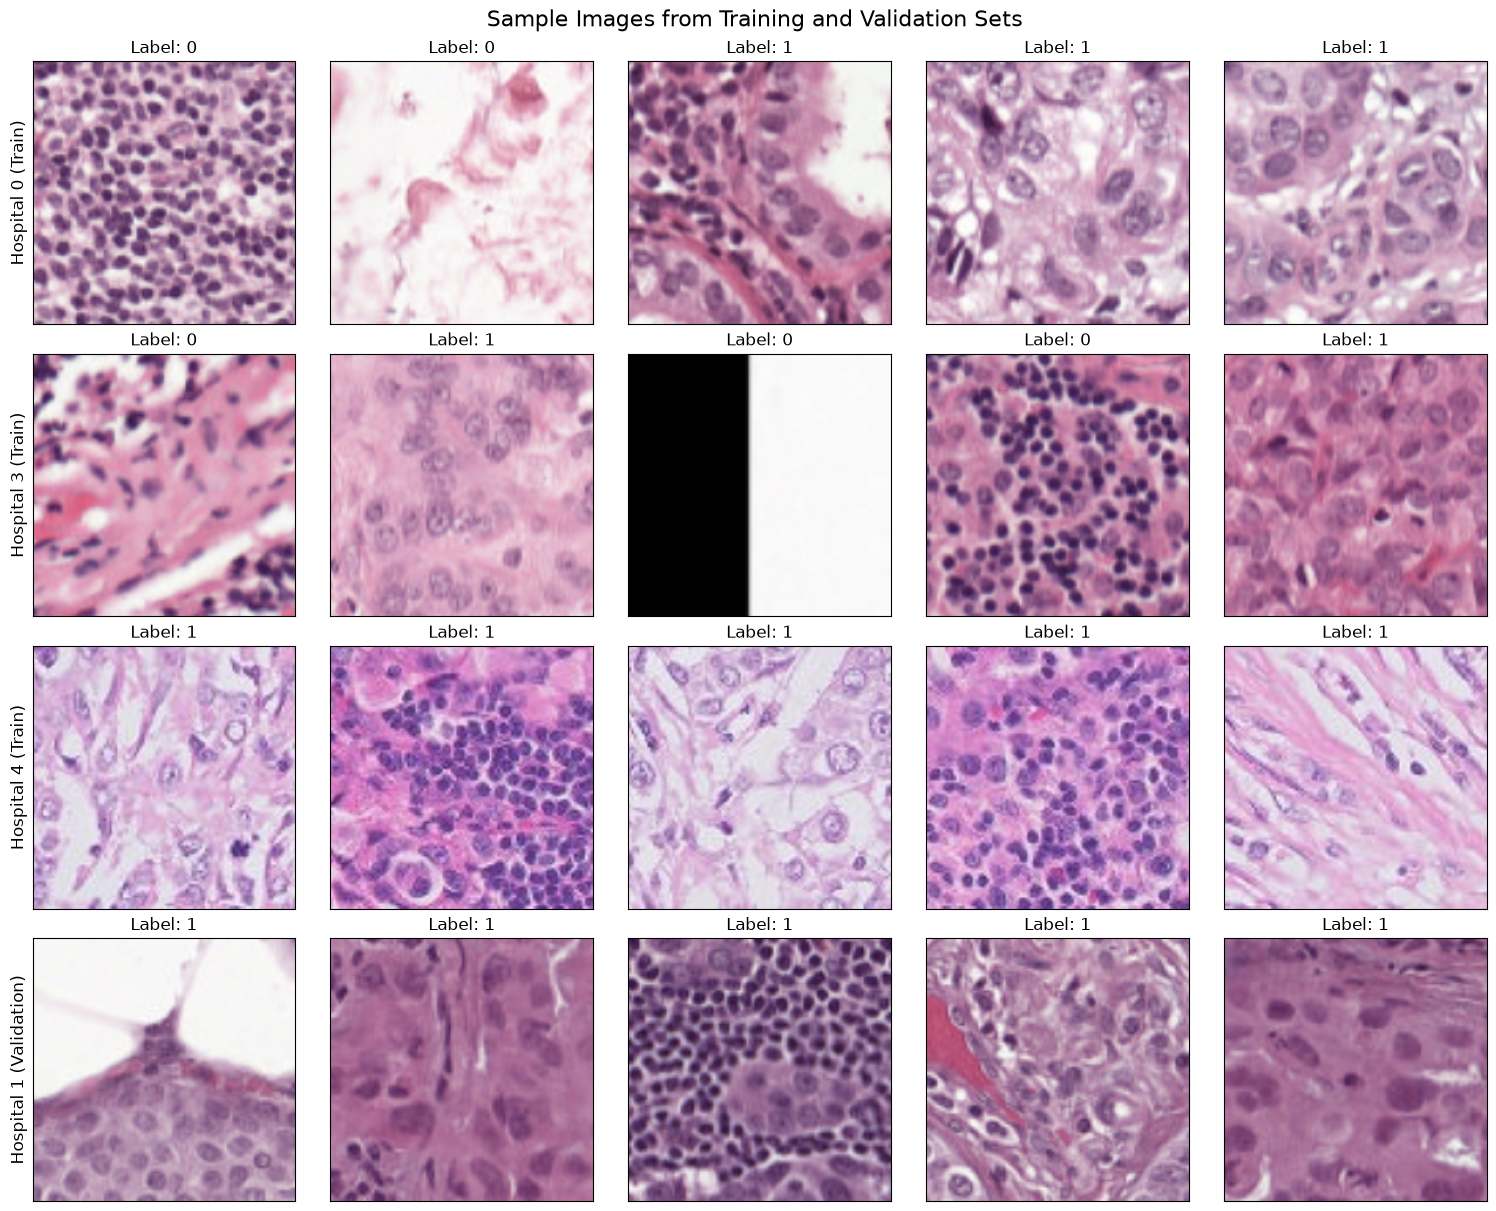

In [5]:
def denormalize(image: torch.Tensor) -> torch.Tensor:
    """Denormalizes an image tensor."""
    mean = torch.tensor([0.485, 0.456, 0.406], device=image.device).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=image.device).view(3, 1, 1)
    return (image * std + mean).permute(1, 2, 0)

n = 5

train_hospitals = torch.unique(train_data.metadata_array[:, 0])
val_hospitals = torch.unique(val_data.metadata_array[:, 0])

n_hospitals = len(train_hospitals) + len(val_hospitals)

fig, axes = plt.subplots(n_hospitals, n, figsize=(n * 3, n_hospitals * 3), constrained_layout=True)
for i, hospital in enumerate(train_hospitals):
    hospital_indices = torch.where(train_data.metadata_array[:, 0] == hospital)[0]
    selected_indices = np.random.choice(hospital_indices, n, replace=False)

    axes[i, 0].set_ylabel(f"Hospital {hospital.item()} (Train)", fontsize=12)

    for j, idx in enumerate(selected_indices):
        axes[i, j].set_yticks([])
        axes[i, j].set_xticks([])

        image, label, metadata= train_data[idx]
        axes[i, j].imshow(denormalize(image))  # Convert from (C, H, W) to (H, W, C)
        axes[i, j].set_title(f"Label: {label.item()}")

for i, hospital in enumerate(val_hospitals, start=len(train_hospitals)):
    hospital_indices = torch.where(val_data.metadata_array[:, 0] == hospital)[0]
    selected_indices = np.random.choice(hospital_indices, n, replace=False)

    axes[i, 0].set_ylabel(f"Hospital {hospital.item()} (Validation)", fontsize=12)

    for j, idx in enumerate(selected_indices):
        axes[i, j].set_yticks([])
        axes[i, j].set_xticks([])

        image, label, metadata= val_data[idx]
        axes[i, j].imshow(denormalize(image))
        axes[i, j].set_title(f"Label: {label.item()}")

fig.suptitle("Sample Images from Training and Validation Sets", fontsize=16)

plt.show()


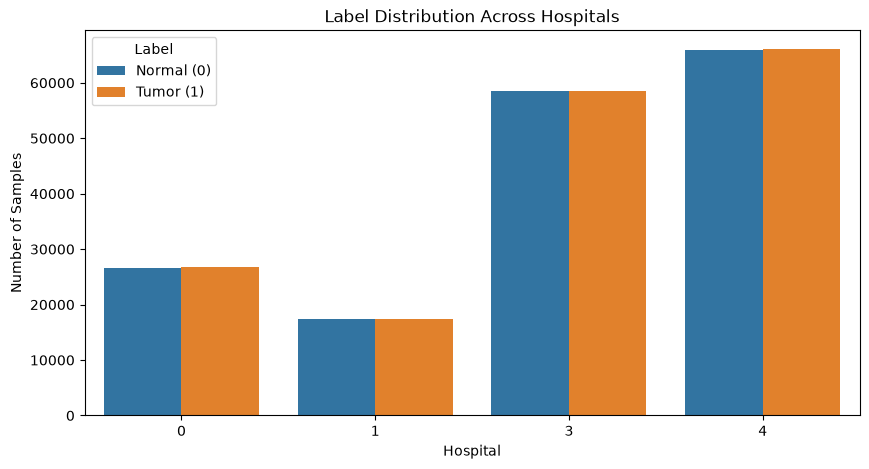

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def get_label_distribution(dataset):
    hospitals = dataset.metadata_array[:, 0].numpy()
    labels = dataset.y_array.numpy()

    return pd.DataFrame({
        "hospital": hospitals,
        "label": labels
    })

train_df = get_label_distribution(train_data)
val_df = get_label_distribution(val_data)

df = pd.concat([
    train_df.assign(split="Train"),
    val_df.assign(split="Validation")
])

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="hospital",
    hue="label"
)

plt.title("Label Distribution Across Hospitals")
plt.xlabel("Hospital")
plt.ylabel("Number of Samples")
plt.legend(title="Label", labels=["Normal (0)", "Tumor (1)"])
plt.show()

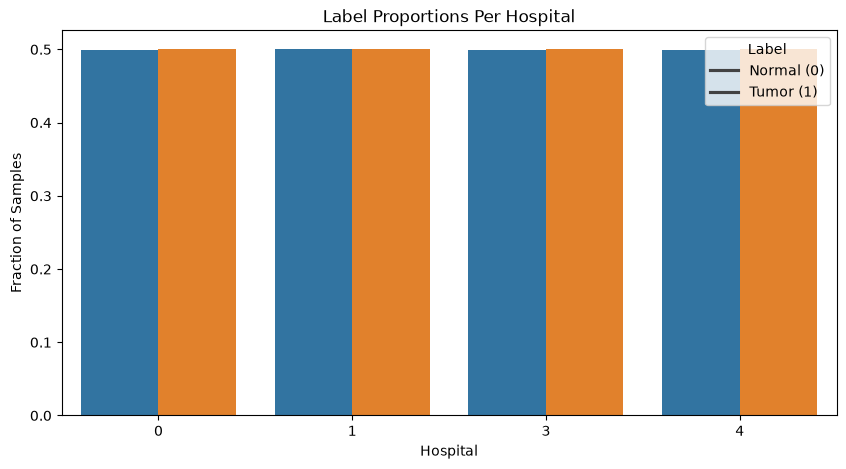

In [7]:
hospital_label_counts = (
    df.groupby(["hospital", "label"])
      .size()
      .reset_index(name="count")
)

hospital_totals = (
    hospital_label_counts.groupby("hospital")["count"]
    .transform("sum")
)

hospital_label_counts["percentage"] = (
    hospital_label_counts["count"] / hospital_totals
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=hospital_label_counts,
    x="hospital",
    y="percentage",
    hue="label"
)

plt.title("Label Proportions Per Hospital")
plt.ylabel("Fraction of Samples")
plt.xlabel("Hospital")
plt.legend(title="Label", labels=["Normal (0)", "Tumor (1)"])

plt.show()

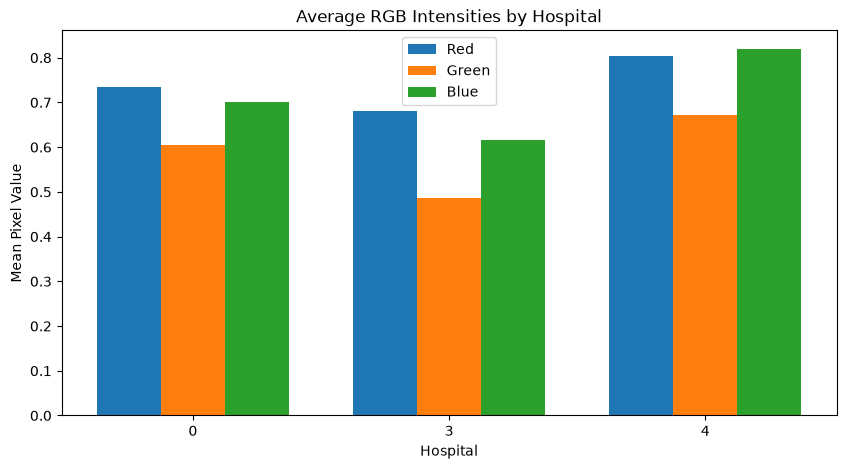

In [8]:
import numpy as np

hospital_means = {}

for hospital in train_hospitals:
    hospital_indices = torch.where(
        train_data.metadata_array[:,0] == hospital
    )[0]

    sample_indices = np.random.choice(
        hospital_indices.numpy(),
        size=min(500, len(hospital_indices)),
        replace=False
    )

    pixels = []

    for idx in sample_indices:
        image, _, _ = train_data[idx]

        image = denormalize(image).numpy()

        pixels.append(image.reshape(-1,3))

    pixels = np.concatenate(pixels, axis=0)

    hospital_means[hospital.item()] = pixels.mean(axis=0)

hospital_ids = list(hospital_means.keys())

r = [hospital_means[h][0] for h in hospital_ids]
g = [hospital_means[h][1] for h in hospital_ids]
b = [hospital_means[h][2] for h in hospital_ids]

x = np.arange(len(hospital_ids))
width = 0.25

plt.figure(figsize=(10,5))

plt.bar(x-width, r, width, label="Red")
plt.bar(x, g, width, label="Green")
plt.bar(x+width, b, width, label="Blue")

plt.xticks(x, hospital_ids)
plt.xlabel("Hospital")
plt.ylabel("Mean Pixel Value")
plt.title("Average RGB Intensities by Hospital")
plt.legend()

plt.show()

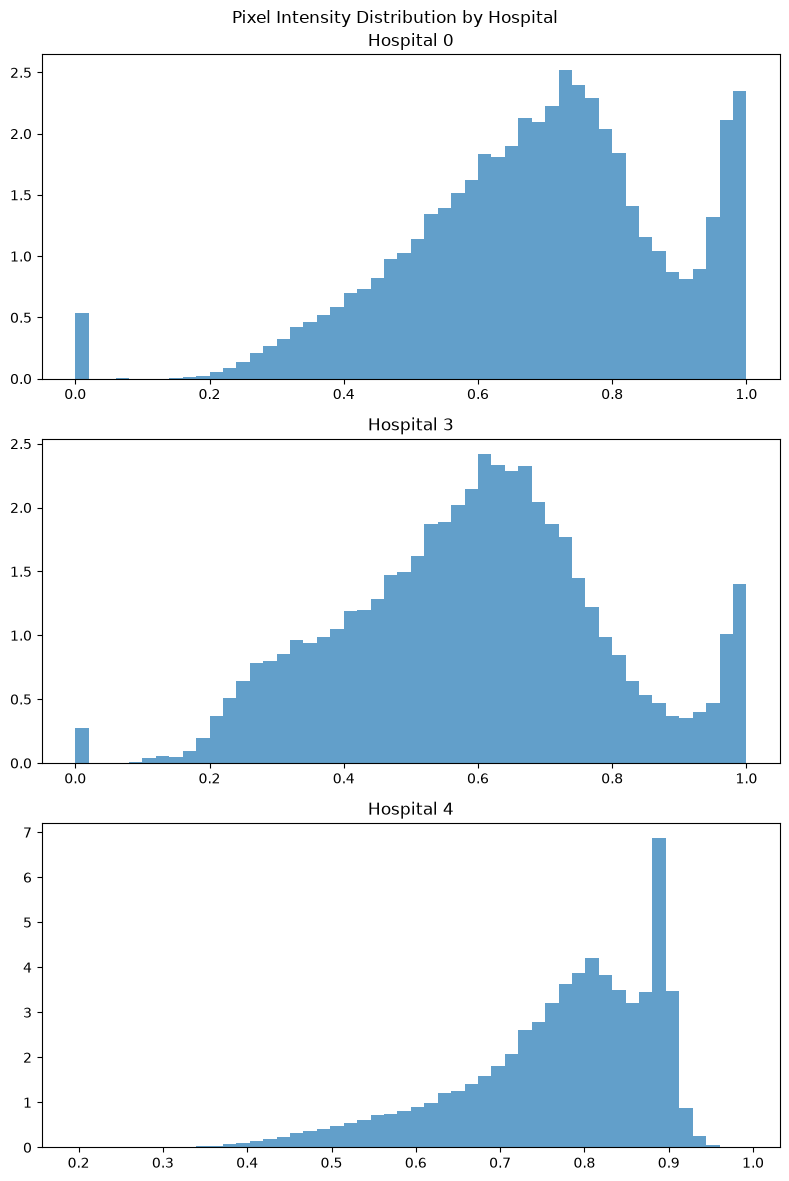

In [9]:
fig, axes = plt.subplots(
    len(train_hospitals),
    1,
    figsize=(8,12)
)

for ax, hospital in zip(axes, train_hospitals):

    hospital_indices = torch.where(
        train_data.metadata_array[:,0] == hospital
    )[0]

    sample_indices = np.random.choice(
        hospital_indices.numpy(),
        size=min(200, len(hospital_indices)),
        replace=False
    )

    pixels = []

    for idx in sample_indices:
        image, _, _ = train_data[idx]
        image = denormalize(image).numpy()

        gray = image.mean(axis=2)
        pixels.append(gray.flatten())

    pixels = np.concatenate(pixels)

    ax.hist(
        pixels,
        bins=50,
        density=True,
        alpha=0.7
    )

    ax.set_title(f"Hospital {hospital.item()}")

plt.suptitle("Pixel Intensity Distribution by Hospital")
plt.tight_layout()
plt.show()

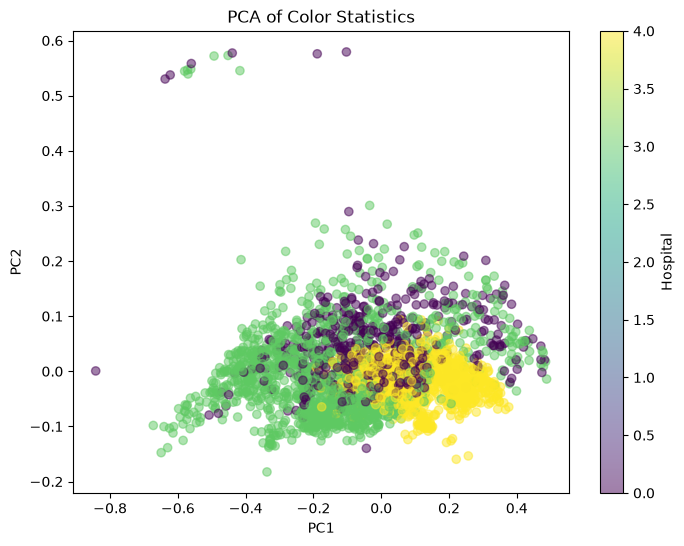

In [10]:
from sklearn.decomposition import PCA

features = []
hospital_ids = []

for idx in np.random.choice(
    len(train_data),
    size=3000,
    replace=False
):

    image, _, metadata = train_data[idx]

    image = denormalize(image).numpy()

    feat = [
        image[:,:,0].mean(),
        image[:,:,1].mean(),
        image[:,:,2].mean(),
        image[:,:,0].std(),
        image[:,:,1].std(),
        image[:,:,2].std(),
    ]

    features.append(feat)
    hospital_ids.append(metadata[0].item())

features = np.array(features)

pca = PCA(n_components=2)
emb = pca.fit_transform(features)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    emb[:,0],
    emb[:,1],
    c=hospital_ids,
    alpha=0.5
)

plt.colorbar(scatter, label="Hospital")
plt.title("PCA of Color Statistics")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

> **Question.** (1.0 pts)
    > 
    > What are your findings? Describe the task, the characteristics you have found, possible challenges that you will encounter, and other initial hypothesis.
    > 
    > Do you think a neural network will be able to classify tumors and generalize to other hospitals?

The Camelyon17 dataset consists of a binary classification task in which histopathology image patches must be classified as either normal tissue (label 0) or tumor tissue (label 1). Visual inspection of the samples shows clear morphological differences between the classes, with tumor patches generally presenting higher cellular density, larger and more irregular nuclei, and less organized tissue structures. 

The label distribution analysis revealed that the dataset is almost perfectly balanced across all hospitals, meaning that class imbalance is unlikely to be a major challenge. However, noticeable variations in color, brightness, contrast, and staining patterns can be observed between hospitals, reflecting differences in scanners and staining protocols. This observation is supported by the PCA analysis, which shows overlapping but distinct distributions among hospitals, with hospitals 0 and 3 exhibiting greater variability than hospital 4. These findings suggest that the main challenge is not class imbalance but domain shift, since the model must generalize to data from an unseen hospital during testing. A potential risk is that the model learns hospital-specific visual characteristics rather than biologically meaningful tumor features, leading to a drop in performance on out-of-distribution data. 

Based on these observations, the initial hypothesis is that a neural network should be capable of achieving strong performance in tumor classification because the morphological differences between classes are visually evident. However, some degradation is expected when evaluating on unseen hospitals due to distribution shifts. Nevertheless, because the PCA results indicate substantial overlap between hospitals rather than completely separate clusters, it is reasonable to expect that a properly regularized neural network, especially when combined with data augmentation techniques such as color perturbations, will be able to learn robust features and generalize reasonably well across different hospitals, although an ID–OOD performance gap will likely remain.

---

## Experiment 1: Transfer Model (Baseline)

[ResNet-18](https://arxiv.org/abs/1512.03385) is a convolutional neural network pretrained on ImageNet, a large-scale dataset of natural images spanning 1,000 object categories.
It is one of the most widely used backbones in transfer-learning pipelines due to its representation capacity across a broad domain of images.
Although it is often treated as a generic feature extractor, its architecture embeds several structural assumptions about images, which become encoded in the learned weights.
When transferring the model to histopathology, it is not immediately clear which of these assumptions remain useful, which are irrelevant, and which may even be harmful.

> **Question:**
>
>What inductive biases does a pretrained ResNet-18 inherit from pretraining on ImageNet, and do they transfer to histopathology?

> **Hypothesis:** 
>
> A pretrained ResNet-18 encodes local visual structures via hierarchical convolutional filters that generalize beyond natural images.
> As a result, a **linear classifier** trained on top of *frozen* ResNet features (a linear probe) should achieve accuracy substantially above 50% on both ID validation and OOD test data, despite the large domain gap between natural and histopathology images.

> **Baseline:**
>
> Random chance is 50% accuracy for balanced binary classification.

In [11]:
# Representation cached from the ResNet-18 backbone

backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
backbone.fc = nn.Identity()  # Remove the final classification layer to get features instead of predictions.

train_loader = get_train_loader("standard", train_data, batch_size=128, num_workers=4)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False, num_workers=4)

with torch.no_grad():
    backbone.eval()
    backbone.to(DEVICE)

    train_features = []
    train_labels = []
    for images, labels, _ in train_loader:
        images = images.to(DEVICE)
        features = backbone(images).cpu()
        train_features.append(features)
        train_labels.append(labels)

    val_features = []
    val_labels = []
    for images, labels, _ in val_loader:
        images = images.to(DEVICE)
        features = backbone(images).cpu()
        val_features.append(features)
        val_labels.append(labels)


resnet_train_dataset = TensorDataset(torch.cat(train_features), torch.cat(train_labels))
resnet_val_dataset = TensorDataset(torch.cat(val_features), torch.cat(val_labels))

In [12]:
# You can modify the following methods as you want.

def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    n_epochs: int   
) -> dict[str, list[float]]:
    """Trains the model and returns the training history."""
    history = {
        "loss": [],
        "epoch_loss": [],
    }

    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0
        n_batches = len(train_loader)

        for features, labels in train_loader:

            features = features.to(DEVICE)
            labels = labels.float().unsqueeze(1).to(DEVICE)

            optimizer.zero_grad()
            outputs = model(features)

            loss = criterion(outputs, labels)
            loss.backward()

            optimizer.step()

            history["loss"].append(loss.item())
            epoch_loss += loss.item() * features.size(0)

        epoch_loss /= len(train_loader.dataset)
        history["epoch_loss"].append(epoch_loss)

        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss:.4f}                            ")

    return history

def evaluate_model(model: nn.Module, data_loader: DataLoader) -> dict[str, float]:
    """Evaluates the model on the given data loader and returns the AUC-ROC score."""
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():

        for features, labels in data_loader:

            features = features.to(DEVICE)

            outputs = model(features)

            probs = torch.sigmoid(outputs)

            all_probs.extend(
                probs.cpu().numpy().flatten()
            )

            all_labels.extend(
                labels.numpy().flatten()
            )

    auc_roc = float(roc_auc_score(all_labels, all_probs))
    
    preds = (
        np.array(all_probs) > 0.5
    ).astype(int)

    accuracy =  float(accuracy_score(all_labels, preds))
    
    return {
        "auc_roc": float(auc_roc),
        "accuracy": float(accuracy)
    }


In [13]:
class LinearProbe(nn.Module):
    """Linear probe on top of the ResNet-18 backbone."""
    def __init__(self, input_dim: int, num_classes: int) -> None:
        super().__init__()
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.fc(x)

In [14]:
train_loader = DataLoader(resnet_train_dataset, batch_size=128, shuffle=True, num_workers=4)
val_loader = DataLoader(resnet_val_dataset, batch_size=128, shuffle=False, num_workers=4)

model = LinearProbe(input_dim=512, num_classes=1).to(DEVICE)

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)
criterion = nn.BCEWithLogitsLoss()

history = train_model(model, train_loader, criterion, optimizer, n_epochs=5)

Epoch 1/5, Loss: 0.1854                            
Epoch 2/5, Loss: 0.1486                            
Epoch 3/5, Loss: 0.1417                            
Epoch 4/5, Loss: 0.1380                            
Epoch 5/5, Loss: 0.1357                            


In [15]:
results = evaluate_model(
    model,
    val_loader
)

print(results)

{'auc_roc': 0.946972772021976, 'accuracy': 0.8778650011460004}


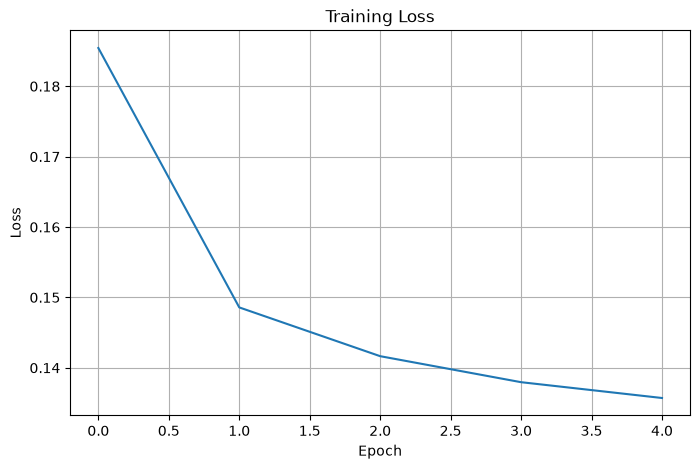

In [16]:
plt.figure(figsize=(8,5))

plt.plot(history["epoch_loss"])

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.grid(True)

plt.show()

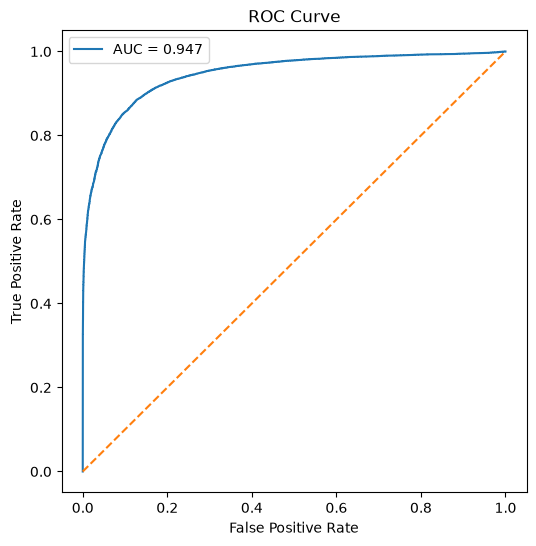

In [17]:
from sklearn.metrics import roc_curve

model.eval()

all_labels = []
all_probs = []

with torch.no_grad():

    for features, labels in val_loader:

        features = features.to(DEVICE)

        outputs = model(features)

        probs = torch.sigmoid(outputs)

        all_probs.extend(
            probs.cpu().numpy().flatten()
        )

        all_labels.extend(
            labels.numpy().flatten()
        )

fpr, tpr, _ = roc_curve(
    all_labels,
    all_probs
)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {results['auc_roc']:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

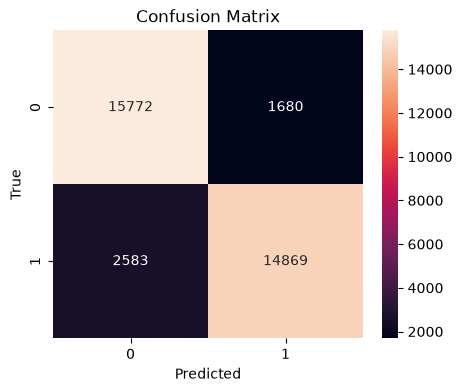

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

preds = (
    np.array(all_probs) > 0.5
).astype(int)

cm = confusion_matrix(
    all_labels,
    preds
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

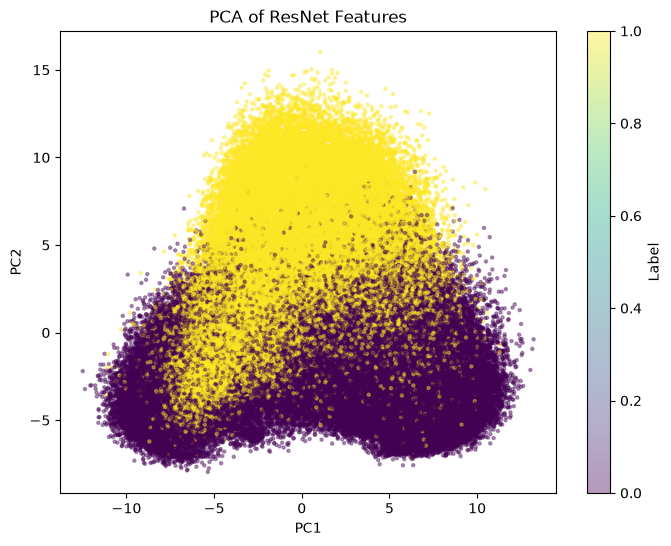

In [19]:
from sklearn.decomposition import PCA

features = torch.cat(
    train_features
).numpy()

labels = torch.cat(
    train_labels
).numpy()

pca = PCA(n_components=2)

emb = pca.fit_transform(features)

plt.figure(figsize=(8,6))

plt.scatter(
    emb[:,0],
    emb[:,1],
    c=labels,
    s=5,
    alpha=0.4
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of ResNet Features")

plt.colorbar(label="Label")

plt.show()

### Design justification

> **Question.** (1.0 pts)
> 
> Why changing only the last layer of the pretrained ResNet-18 is a reasonable baseline for this dataset?
>
> Explain what were the metrics that you used to test the hypothesis and why they help answering the question.

Using a pretrained ResNet-18 with only the final layer replaced is a reasonable baseline for Camelyon17 because it isolates the quality of the representations learned during ImageNet pretraining. By freezing the backbone and training only a linear classifier, we can directly evaluate whether the extracted features already contain information useful for distinguishing tumor from normal tissue. This approach is computationally efficient, reduces the risk of overfitting, and provides a clear measure of transferability from natural images to histopathology images. If a simple linear layer can achieve good performance, it suggests that the pretrained convolutional filters have learned generic visual features such as edges, textures, shapes, and local patterns that remain relevant outside the ImageNet domain.

To evaluate the hypothesis, we used Accuracy and AUC-ROC. Accuracy measures the fraction of correctly classified samples and is appropriate because the dataset is balanced between normal and tumor patches, making the random baseline exactly 50%. AUC-ROC measures the model's ability to rank tumor samples above normal samples across all possible decision thresholds. Unlike accuracy, AUC is insensitive to the choice of classification threshold and provides a more robust assessment of the discriminative quality of the learned representations. Together, these metrics allow us to determine whether the frozen ImageNet features contain meaningful information for tumor detection

### Discussion

> **Question.** (1.0 pts) 
> 
> Discuss the results of using a frozen backbone. Address the following points:
> 
> Do the results support or contradict the hypothesis? Refer to specific numbers.
>
> What does the gap between metrics ID vs OOD imply about the representations?
>
> What limitations does the linear probe evaluation have when assessing the quality of the pretrained representations?
> Can we correctly attribute what is causing the observed performance?

The results support the hypothesis that ImageNet-pretrained ResNet-18 features transfer effectively to histopathology images. The linear probe achieved 87.85% accuracy and 0.947 AUC-ROC, substantially outperforming the random baseline of 50% accuracy and 0.5 AUC. The steadily decreasing training loss (from 0.1811 to 0.1357) further indicates that the frozen representations contain useful information for distinguishing tumor from normal tissue.

The PCA visualization suggests that the pretrained features already separate the two classes to a significant extent, while the ROC curve confirms strong discriminative ability across different classification thresholds. Together, these results indicate that the convolutional filters learned from ImageNet capture generic visual patterns that remain useful in a very different domain.

However, this experiment only evaluates performance on the validation hospital, so it does not yet allow us to measure the ID–OOD gap. Evaluating on the unseen hospital is necessary to determine how well these representations generalize across different staining protocols and scanners.

A limitation of the linear probe is that it only measures the information already present in the frozen representation. It does not indicate how much performance could be gained through fine-tuning, nor does it reveal which specific visual features are responsible for the predictions. Therefore, although the results demonstrate successful transfer learning, they do not allow us to conclude whether the model is relying primarily on tumor morphology or on hospital-specific visual characteristics.

In [36]:
torch.save(
    {
        "train_features": torch.cat(train_features),
        "train_labels": torch.cat(train_labels),
        "val_features": torch.cat(val_features),
        "val_labels": torch.cat(val_labels),
    },
    "resnet_features.pt"
)

---

## Experiment 2: Is the CNN Structure Necessary?

ResNet is a convolutional architecture, meaning it builds in several strong assumptions: 
- local feature detection via small kernels
- spatial weight sharing
- hierarchical composition of features

These are not universal truths about image data, they are inductive biases that may or may not be useful for a given task.

A model with no spatial inductive bias, such as a multilayer perceptron (MLP) applied to flattened pixels, treats every pixel independently and must learn spatial relationships from data alone.
Comparing the two isolates the contribution of the convolutional inductive bias from all other factors.

This comparison also illustrates a central theme of this assignment: **raw parameter count does not determine generalization**.
As you will see, the MLP on 96×96×3 input has a first hidden layer alone with more parameters than the entire CNN, yet it may perform worse, demonstrating that inductive alignment with the data structure matters more than model capacity.

Note that, as we changed a lot of things when compared with the previous experiment, we cannot make a direct comparison, but we can see the performance on a baseline that already solves the problem.

> **Question:** Does the spatial inductive bias of a convolutional architecture improve generalization over a non-spatial model with comparable or greater parameter count?

### Hypothesis

> **Hypothesis.** (1.0 pts)
>
> *State a falsifiable hypothesis. Your hypothesis should make a concrete, directional prediction about the ID accuracy, OOD accuracy, and/or ID–OOD gap for the MLP vs SmallCNN. Refer to specific structural properties you expect to matter.*



Hypothesis. The SmallCNN will achieve higher validation (ID) and test (OOD) performance than the MLP, despite having a similar or smaller number of parameters. The convolutional architecture incorporates spatial inductive biases such as local feature detection, weight sharing, and hierarchical feature composition, which are well aligned with histopathology images where tumor patterns are defined by local cellular structures and tissue organization. In contrast, the MLP treats each pixel independently and must learn spatial relationships directly from the data, making it less data-efficient and more prone to overfitting. Therefore, we expect the SmallCNN to obtain higher accuracy and AUC on both ID and OOD data, as well as a smaller ID–OOD performance gap, indicating better generalization to unseen hospitals.

In [20]:
class MLP(nn.Module):
    """Fully connected network."""

    def __init__(self, input_size, hidden_dims=[512, 256], dropout=0.3):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_dims[0]),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dims[1], 1)
        )

    def forward(self, x):

        x = x.view(x.size(0), -1)

        return self.network(x)


class SmallCNN(nn.Module):
    """Small convolutional network."""

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, 1)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x


In [21]:
# For this experiment, you can change the data transforms if you want.
# We recommend using smaller input sizes (e.g., the raw data is 96×96)
# for the MLP and SmallCNN, since they have fewer parameters than the ResNet-18
# and will overfit more easily on the full 224×224 images.
# You can use the same normalization as before, or recompute the mean and std
# on the smaller input size.

SIZE = 96

transform = transforms.Compose(
    [
        # You can uncomment the line below if you want to use a different input size.
        # transforms.Resize((SIZE, SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), 
    ]
)

train_data = dataset.get_subset("train", transform=transform)
val_data = dataset.get_subset("val", transform=transform)
test_data = dataset.get_subset("test", transform=transform)

In [22]:
mlp_input_dim = SIZE * SIZE * 3  # 96 × 96 × 3 = 27,648

mlp = MLP(input_size=mlp_input_dim, hidden_dims=[512, 256], dropout=0.3).to(DEVICE)
cnn = SmallCNN().to(DEVICE)


def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print(f"MLP total parameters : {count_params(mlp):>12,}")
print(f"CNN total parameters : {count_params(cnn):>12,}")
print()
print("Note: both models receive the same 96×96×3 input and the same training procedure.")

MLP total parameters :   14,287,873
CNN total parameters :       93,825

Note: both models receive the same 96×96×3 input and the same training procedure.


In [23]:
train_loader = get_train_loader("standard", train_data, batch_size=128, num_workers=4)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False, num_workers=4)

# Hint: Even though the models are different, you can use the same training loop and the same hyperparameters
# (e.g., learning rate, optimizer, number of epochs) for both models to make a fair comparison.
# You can also do hyperparameter tuning for each model separately if you want.

# The important thing is to ensure that both models are trained under similar conditions, or that both
# are given the opportunity to perform their best (e.g., by tuning hyperparameters separately).
# If your CNN, for example, performs much better than the MLP, but they were trained with very different setups,
# it is harder to convincingly argue that the CNN's superior performance is due to its architecture rather than the training procedure.

learning_rate = 1e-3
n_epochs = 10
dropout = 0.3

In [24]:
def train_image_model(
    model,
    train_loader,
    criterion,
    optimizer,
    n_epochs
):

    history = {
        "loss": [],
        "epoch_loss": []
    }

    for epoch in range(n_epochs):

        model.train()

        epoch_loss = 0

        for images, labels, _ in train_loader:

            images = images.to(DEVICE)
            labels = labels.float().unsqueeze(1).to(DEVICE)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item() * images.size(0)

        epoch_loss /= len(train_loader.dataset)

        history["epoch_loss"].append(epoch_loss)

        print(
            f"Epoch {epoch+1}/{n_epochs} | Loss: {epoch_loss:.4f}"
        )

    return history

In [25]:
mlp_optimizer = optim.Adam(
    mlp.parameters(),
    lr=learning_rate
)

mlp_criterion = nn.BCEWithLogitsLoss()

train_mlp_history = train_image_model(mlp, train_loader, mlp_criterion, mlp_optimizer, n_epochs=n_epochs)

Epoch 1/10 | Loss: 0.5654
Epoch 2/10 | Loss: 0.4776
Epoch 3/10 | Loss: 0.4528
Epoch 4/10 | Loss: 0.4336
Epoch 5/10 | Loss: 0.4211
Epoch 6/10 | Loss: 0.4064
Epoch 7/10 | Loss: 0.3980
Epoch 8/10 | Loss: 0.3888
Epoch 9/10 | Loss: 0.3888
Epoch 10/10 | Loss: 0.3784


In [27]:
cnn_optimizer = optim.Adam(
    cnn.parameters(),
    lr=learning_rate
)

cnn_criterion = nn.BCEWithLogitsLoss()

# CNN training might be slower than MLP training, so you can reduce the number of epochs for the CNN if needed.
train_cnn_history = train_image_model(cnn, train_loader, cnn_criterion, cnn_optimizer, n_epochs=5)

Epoch 1/5 | Loss: 0.0923
Epoch 2/5 | Loss: 0.0790
Epoch 3/5 | Loss: 0.0710
Epoch 4/5 | Loss: 0.0650
Epoch 5/5 | Loss: 0.0601


In [29]:
from sklearn.metrics import roc_auc_score, accuracy_score

def evaluate_image_model(model, data_loader):

    model.eval()

    all_labels = []
    all_probs = []

    with torch.no_grad():

        for images, labels, _ in data_loader:

            images = images.to(DEVICE)

            outputs = model(images)

            probs = torch.sigmoid(outputs)

            all_probs.extend(
                probs.cpu().numpy().flatten()
            )

            all_labels.extend(
                labels.numpy().flatten()
            )

    auc_roc = roc_auc_score(
        all_labels,
        all_probs
    )

    preds = (
        np.array(all_probs) > 0.5
    ).astype(int)

    accuracy = accuracy_score(
        all_labels,
        preds
    )

    return {
        "auc_roc": float(auc_roc),
        "accuracy": float(accuracy)
    }

In [31]:
mlp_results = evaluate_image_model(
    mlp,
    val_loader
)

cnn_results = evaluate_image_model(
    cnn,
    val_loader
)

print("MLP")
print(mlp_results)

print()

print("CNN")
print(cnn_results)

MLP
{'auc_roc': 0.7712028224995797, 'accuracy': 0.6392390556956222}

CNN
{'auc_roc': 0.9157731048979423, 'accuracy': 0.7774467109786843}


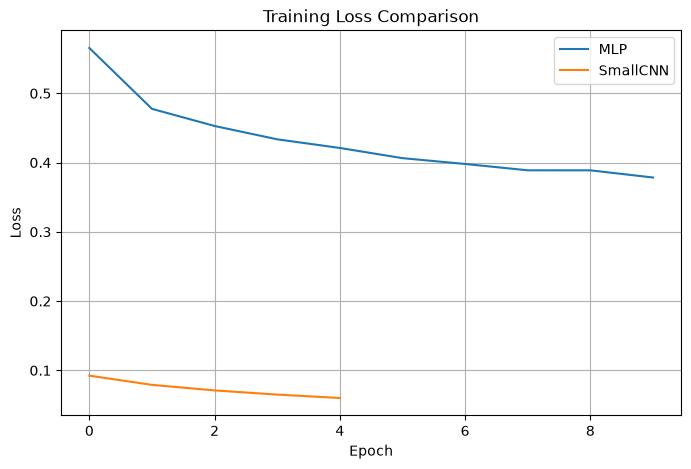

In [32]:
plt.figure(figsize=(8,5))

plt.plot(
    train_mlp_history["epoch_loss"],
    label="MLP"
)

plt.plot(
    train_cnn_history["epoch_loss"],
    label="SmallCNN"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")

plt.legend()
plt.grid(True)

plt.show()

In [38]:
from sklearn.metrics import roc_curve, auc

def get_predictions(model, loader):

    model.eval()

    probs = []
    labels_all = []

    with torch.no_grad():

        for images, labels, _ in loader:

            images = images.to(DEVICE)

            outputs = model(images)

            prob = torch.sigmoid(outputs)

            probs.extend(
                prob.cpu().numpy().flatten()
            )

            labels_all.extend(
                labels.numpy()
            )

    return np.array(labels_all), np.array(probs)

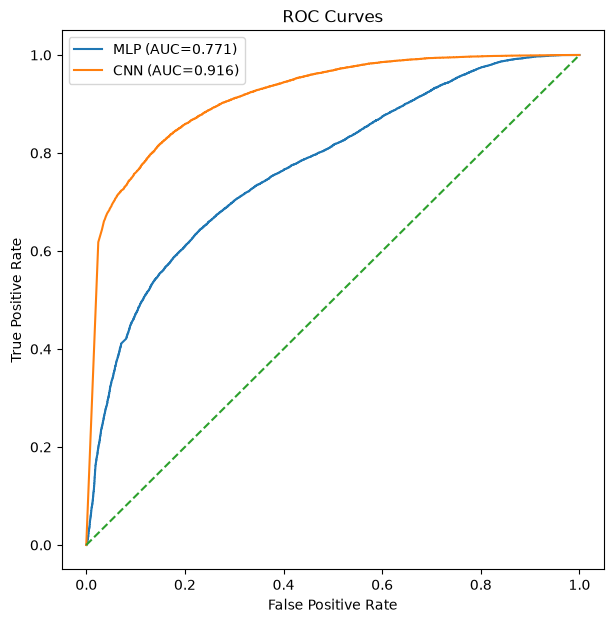

In [39]:
mlp_labels, mlp_probs = get_predictions(
    mlp,
    val_loader
)

cnn_labels, cnn_probs = get_predictions(
    cnn,
    val_loader
)

fpr_mlp, tpr_mlp, _ = roc_curve(
    mlp_labels,
    mlp_probs
)

fpr_cnn, tpr_cnn, _ = roc_curve(
    cnn_labels,
    cnn_probs
)

plt.figure(figsize=(7,7))

plt.plot(
    fpr_mlp,
    tpr_mlp,
    label=f"MLP (AUC={mlp_results['auc_roc']:.3f})"
)

plt.plot(
    fpr_cnn,
    tpr_cnn,
    label=f"CNN (AUC={cnn_results['auc_roc']:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")

plt.legend()

plt.show()

In [41]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

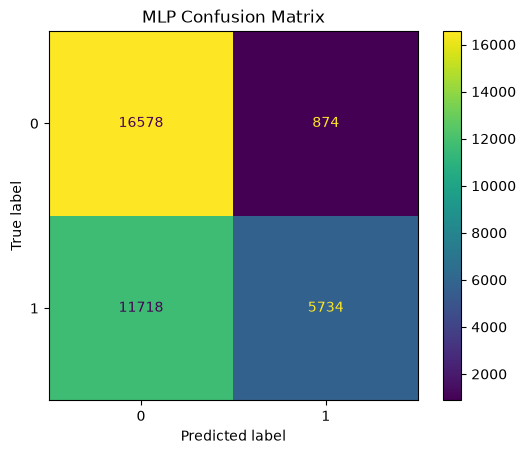

In [42]:
mlp_preds = (
    mlp_probs > 0.5
).astype(int)

cm_mlp = confusion_matrix(
    mlp_labels,
    mlp_preds
)

ConfusionMatrixDisplay(
    cm_mlp
).plot()

plt.title("MLP Confusion Matrix")

plt.show()

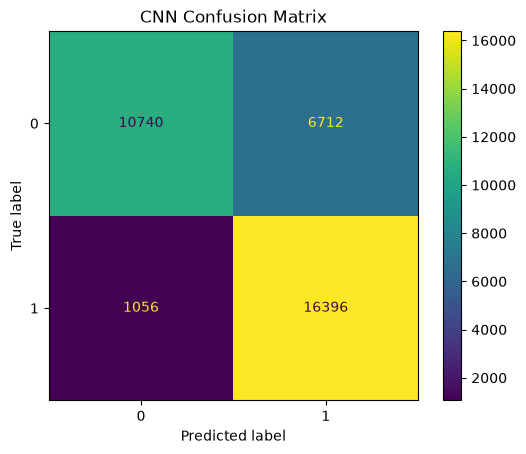

In [43]:
cnn_preds = (
    cnn_probs > 0.5
).astype(int)

cm_cnn = confusion_matrix(
    cnn_labels,
    cnn_preds
)

ConfusionMatrixDisplay(
    cm_cnn
).plot()

plt.title("CNN Confusion Matrix")

plt.show()

In [33]:
torch.save(
    mlp.state_dict(),
    "mlp_camelyon.pth"
)

torch.save(
    cnn.state_dict(),
    "cnn_camelyon.pth"
)

In [34]:
import pickle

with open("mlp_history.pkl", "wb") as f:
    pickle.dump(train_mlp_history, f)

with open("cnn_history.pkl", "wb") as f:
    pickle.dump(train_cnn_history, f)

In [37]:
import json

results = {
    "mlp": mlp_results,
    "cnn": cnn_results
}

with open("results.json", "w") as f:
    json.dump(results, f, indent=4)

### Design justification

> **Question.** (1.0 pts)
>
> Why comparing MLP vs SmallCNN (both trained from scratch on the same data) isolates the contribution of the convolutional inductive bias?
> 
> What aspect of the your implementation makes it an atomic ablation?

Comparing an MLP and a SmallCNN trained from scratch on the same dataset isolates the contribution of the convolutional inductive bias because both models are exposed to the same training data, preprocessing pipeline, optimization procedure, and learning objective. The main difference between them is architectural: the CNN incorporates spatial assumptions through local receptive fields, weight sharing, and hierarchical feature extraction, while the MLP treats the image as a flat vector and must learn spatial relationships directly from the data. Therefore, differences in performance can be largely attributed to the presence or absence of these convolutional biases.

This experiment constitutes an atomic ablation because only one fundamental component of the learning system is changed: the architecture. Both models were trained from scratch on the same Camelyon17 training set using the same input images, loss function, optimizer, and evaluation protocol. By controlling the remaining factors, the experiment isolates the effect of spatial inductive bias on learning and generalization.

### Discussion

> **Question.** (1.0 pts) 
> 
> Discuss the results of using MLP vs CNN in generalization. Address the following points:
> 
> Do the results support or contradict your hypothesis? Refer to specific metric values.
>
> Compare the ID–OOD gap for MLP vs CNN. Which model generalizes better to the unseen center, and why might that be?
>
> The MLP has more parameters than the CNN, did this fact influenced the generalization aspect of the MLP?
>
> How do the from-scratch models compare to the frozen ResNet from Experiment 1?

The results support the hypothesis. The SmallCNN substantially outperformed the MLP on the validation set, achieving 77.7% accuracy and 0.916 AUC, compared to 63.9% accuracy and 0.771 AUC for the MLP. The CNN also converged much faster during training, reaching a final loss of 0.060, whereas the MLP finished with a considerably higher loss of 0.378. These results indicate that the convolutional architecture is significantly more effective at extracting relevant information from histopathology images.

Although OOD results are required to directly compare the ID–OOD gap, the stronger validation performance of the CNN suggests that it is likely to generalize better to unseen hospitals. Histopathology images contain local cellular structures, textures, and spatial arrangements that are naturally captured by convolutional filters. Because the CNN explicitly exploits these properties through local feature extraction and weight sharing, it can learn more robust and transferable representations. In contrast, the MLP must learn spatial relationships from individual pixels, making it more prone to fitting dataset-specific patterns and less likely to generalize across centers with different staining and imaging conditions.

An interesting observation is that the MLP contains substantially more parameters than the CNN due to its large fully connected first layer. Despite this larger capacity, the MLP achieved worse performance. This suggests that model size alone is not sufficient for good generalization. In fact, the larger parameter count may have made the MLP more susceptible to memorizing training patterns instead of learning meaningful spatial structures. The results demonstrate that an architecture whose inductive biases are aligned with the data can outperform a much larger model.

Comparing these models with the frozen ResNet from Experiment 1 highlights the importance of both architecture and pretraining. The linear probe on top of the pretrained ResNet achieved 87.8% accuracy and 0.947 AUC, outperforming both the CNN and the MLP trained from scratch. This indicates that the representations learned from ImageNet transfer effectively to histopathology and provide a strong initialization that cannot be matched by small models trained only on Camelyon17. At the same time, the CNN's clear advantage over the MLP reinforces the conclusion that convolutional inductive biases are valuable for this task. Together, the experiments suggest that both appropriate architectural assumptions and transferable pretrained representations contribute to successful generalization.

---

## Experiment 3: Are Colors a Required Feature?

A potential issue in the data is that, different hospitals use different techniques for collecting data.
One example of such change is how the stain intensity shift across hospital centers.

Because each center has a different scanner and staining protocol, the color distribution of a patch partially encodes which hospital it came from.
This creates a potential **spurious correlation**: a model trained on centers 0–2 may learn to use color as a predictive cue, even though color is determined by the imaging center rather than by tumor status.

Under center shift (training on centers 0–2, testing on center 4), a model that relies on color will encounter a new color distribution and may fail even if the morphological signal is present.

> **Question:** Does the previous CNN rely on color information to predict tumor status, and does removing color change the generalizaion gap?

### Hypothesis

> **Hypothesis.** (1.0 pts)
>
> *State a falsifiable hypothesis. Your hypothesis should predict the direction of the change in ID accuracy, OOD accuracy, and/or ID–OOD gap when switching from RGB to grayscale input. Relate your prediction to the color distribution visualization from the Data Exploration section.*

*YOUR ANSWER HERE*

In [ ]:
# Maintain the same configurations you set on the previous cells (e.g. input size, normalization, etc.) to
# isolate the effect of changing the data assumptions.

transform = transforms.Compose(
    [
        # Uncomment the line below if you want to use a different input size.
        # transforms.Resize((SIZE, SIZE)),
        transforms.Grayscale(num_output_channels=3),  # Convert to 3-channel grayscale to use the same architecture as before.
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ]
)

train_data = dataset.get_subset("train", transform=transform)
val_data = dataset.get_subset("val", transform=transform)
test_data = dataset.get_subset("test", transform=transform)

In [ ]:
# Your code here
# Train, evaluate and analyze.

### Design justification

> **Question.** (1.0 pts)
>
> Explain your experiment configuration, state what remained the same from the previous experiment, and what have changed.
>
> How does your experiment answer the question?

*YOUR ANSWER HERE*

### Discussion

> **Question.** (1.0 pts) 
> 
> Discuss the results of removing the color feature. Address the following points:
> 
> Does removing color improve or degrade ID metrics? OOD metrics? Was this consistent with your hypothesis?
>
> Can we attribute the results uniquely to the color change?
>
> How does it connect with the Data exploration you conducted?

*YOUR ANSWER HERE*

---

## Model Selection: Choosing the final model

The three previous experiments provide evidence about what drives and what hinders generalization in this setting:

- **Experiment 1** established the baseline: a linear probe on frozen pretrained features achieves some performance, with a measurable ID–OOD gap.
- **Experiment 2** assessed whether spatial inductive bias matters.
- **Experiment 3** assessed whether color is a spurious or informative feature.

In this experiment you will use those observations to motivate a final model of your choice and test whether it generalizes for the test dataset.

You don't need to state a hypothesis, or justify your design here.
Experiment with different settings and suppositions until you converge with the best model that might well generalize.
You can use ResNet, or a network from scratch, just report the number of parameters on the final model and the time it took to
train.

> **Question**
>
> Based on the evidence from previous experiments, propose a deep neural network that might reduce the ID–OOD generalization gap.

In [ ]:
# TODO: Implement your final model (you can choose any architecture you want, including the ones you implemented before) and train it on the dataset.
# Some suggestions:
# - You can use the ResNet-18 backbone from Experiment 1 and fine-tune all (or the last N) layers instead of freezing them.
# - You can use the MLP or SmallCNN from Experiment 2 and increase their capacity (e.g., more layers, more hidden units, etc.).
# - You can change the data transforms (e.g., input size, normalization, data augmentation, etc.) to see if it improves the performance of the models.
# - You can use other loss functions (e.g., focal loss, dice loss, etc.) or optimization algorithms (e.g., AdamW, RMSProp, etc.).
# - A combination of the above suggestions (caution to not change too many things at once, or it will be harder to analyze the results and understand what caused the performance changes).

In [ ]:
# Evaluate your final model, analyze the results.
# Use the same evaluation metrics and plots you used in the previous experiments to analyze the performance of your final model.
# Now, you can also evaluate your final model on the test set, but make sure to only do this after you have finalized your model
# and analysis based on the validation set, to avoid overfitting to the test set.

### Discussion

> **Question.** (1.0 pts) 
> 
> Discuss the results for your final model.
> 
> What is the number of parameters of your model? Compare it with the size of the previous models and draw a link with the results.
>
> What was the training time? Did it take more or less time than the expected?
>
> How does the OOD performance connect with your changes in the data and model?
>
> If your results are positive, can you attribute for certain which aspect of your model mostly contributed for the increase in performance?
> 
> Conversely, if your results are negative (the modification were worse than the experiments), provide an alternative explanation that is consistent with the failure.

*YOUR ANSWER HERE*

---

## Assignment Submission

This notebook must be filled with your solution and submitted on the Assignment's entry at our Google Classroom page.

Before submitting, verify that:
- The notebook runs end-to-end without errors (use **Run All** after restarting the kernel).
- All plots are rendered in the output.
- All written section (Hypothesis, Design, Discussion) are filled in.
- AI usage declaration and prompts are included, if applicable.

**Important: Only one member of the group should submit.**

### Policy for late submissions

You are NOT encouraged to submit after the deadline; however, in this case the following penalties apply:

- 25% deduction for 1-day late submission.
- 50% deduction for 2-day late submission.
- 75% deduction for 3-day late submission.